# 12.4. 수소 분자

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import physical_constants

Eh = physical_constants["Hartree energy in eV"][0]
rng = np.random.default_rng(42)


def S(R):
    return np.exp(-R) * (1 + R + R**2 / 3)


def H_AA(R):
    return -0.5 + np.exp(-2 * R) * (1 + 1 / R)


def H_AB(R):
    return -0.5 * S(R) - np.exp(-R) * (1 + R) + S(R) / R


def sample_1s(n, center, rng):
    """수소 원자의 1s 오비탈의 전자 밀도에서 n개의 점을 뽑는다"""
    r = rng.gamma(3.0, 0.5, n)
    u = rng.normal(size=(n, 3))
    u /= np.linalg.norm(u, axis=1)[:, None]
    return center + r[:, None] * u


def sample_sigma(n, R, rng):
    """|sigma_g|^2 에서 n개의 점을 뽑는다 (기각 표본 추출)"""
    cA = np.array([0, 0, -R / 2.0])
    cB = np.array([0, 0, R / 2.0])
    out, need = [], n
    while need > 0:
        m = int(need * 2.5) + 100
        pick = rng.integers(0, 2, m)
        p = np.where(pick[:, None] == 0, sample_1s(m, cA, rng), sample_1s(m, cB, rng))
        A = np.exp(-np.linalg.norm(p - cA, axis=1))
        B = np.exp(-np.linalg.norm(p - cB, axis=1))
        accept = rng.random(m) < (A + B) ** 2 / (2 * (A**2 + B**2))
        out.append(p[accept])
        need -= accept.sum()
    return np.vstack(out)[:n]

In [2]:
def E_MO(R, n, rng=rng):
    p1 = sample_sigma(n, R, rng)
    p2 = sample_sigma(n, R, rng)
    d = np.linalg.norm(p1 - p2, axis=1)

    J = np.mean(1 / d)
    err = np.std(1 / d) / np.sqrt(n)

    h = (H_AA(R) + H_AB(R)) / (1 + S(R)) - 1 / R
    return 2 * h + J + 1 / R, J, err

    R          J       E_MO     error
 0.40    0.61809    0.22791   0.00081
 0.80    0.60117   -0.83369   0.00079
 1.20    0.57966   -1.05850   0.00077
 1.60    0.55256   -1.09946   0.00073
 2.00    0.52623   -1.08131   0.00067
 3.00    0.46928   -0.98222   0.00062
 4.00    0.42840   -0.89533   0.00062
 5.00    0.40464   -0.83377   0.00064


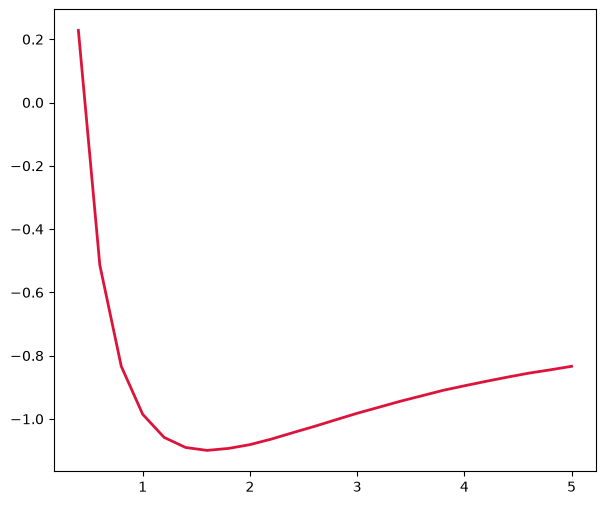


최소점: R = 1.6 bohr, E = -1.0995 hartree


In [3]:
Rs = np.linspace(0.4, 5.0, 24)
n = 400000
Es = []
print(f"{'R':>5} {'J':>10} {'E_MO':>10} {'error':>9}")
for R in Rs:
    E, J, err = E_MO(R, n)
    Es.append(E)
    if np.round(R, 1) in [0.4, 0.8, 1.2, 1.6, 2.0, 3.0, 4.0, 5.0]:
        print(f"{R:5.2f} {J:10.5f} {E:10.5f} {err:9.5f}")

i = int(np.argmin(Es))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(Rs, Es, lw=2, color="crimson")
plt.show()

print(f"\n최소점: R = {Rs[i]} bohr, E = {Es[i]:.4f} hartree")